<a href="https://colab.research.google.com/github/hombremono873/Cuadernos_colab/blob/main/Deteccion__Riesgo_Cardiaco_Red_Neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ** 1. Carga de librerías**

In [ ]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)
import seaborn as sns
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import numpy as np

# **2. Carga y lectura del dataset**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("uditjain13/heart-disease-risk-2026")

print("Path to dataset files:", path)

100%|██████████| 344k/344k [00:00<00:00, 70.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uditjain13/heart-disease-risk-2026/versions/3


In [ ]:
"""
  Lectura del archivo de datos en formato CSv y construcción del dataset
"""
file = os.path.join(path, "heart_disease_risk_2026.csv")
df = pd.read_csv(file)
df.sample(5)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
3528,3529,67,Male,118,83,152,51,82,99,92,...,False,Former,21.4,122,8.4,42.2,True,9163,75.1,0
8768,8769,58,Male,114,77,154,45,97,74,94,...,False,Current,3.0,148,6.8,50.2,False,5989,75.5,1
7795,7796,62,Male,122,82,173,55,90,178,96,...,True,Former,2.3,162,8.8,51.9,False,1845,47.5,1
5003,5004,51,Male,135,96,159,61,82,100,101,...,True,Former,6.0,159,6.0,54.8,True,9375,83.0,0
287,288,55,Male,128,69,202,73,94,150,126,...,False,Former,2.4,240,8.5,47.3,True,5387,67.7,0


## **3. Inspección y análisis global del dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [ ]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [ ]:
print(f"Cantidad de valores nulos {df.isnull().sum()}")
print(f"\n Valores duplicados {df.duplicated().sum()}")

Cantidad de valores nulos patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

 Valores duplicados 0


Correlación de variables numéricas con has_heart_disease:
has_heart_disease            1.000000
max_heart_rate_achieved      0.580704
exercise_induced_angina      0.445412
st_depression                0.356817
age                          0.290954
ldl                          0.267150
hdl                          0.251505
resting_bp_systolic          0.249089
exercise_minutes_per_week    0.248475
hba1c                        0.225830
bmi                          0.213249
fasting_blood_sugar          0.202358
resting_bp_diastolic         0.193104
resting_heart_rate           0.168212
cholesterol_total            0.167516
diet_quality_score           0.155234
daily_steps                  0.152855
triglycerides                0.110365
stress_score                 0.097975
wearable_owner               0.094652
family_history               0.070622
sleep_hours                  0.049797
alcohol_units_per_week       0.041271
patient_id                   0.006946
Name: has_heart_disease, dtype

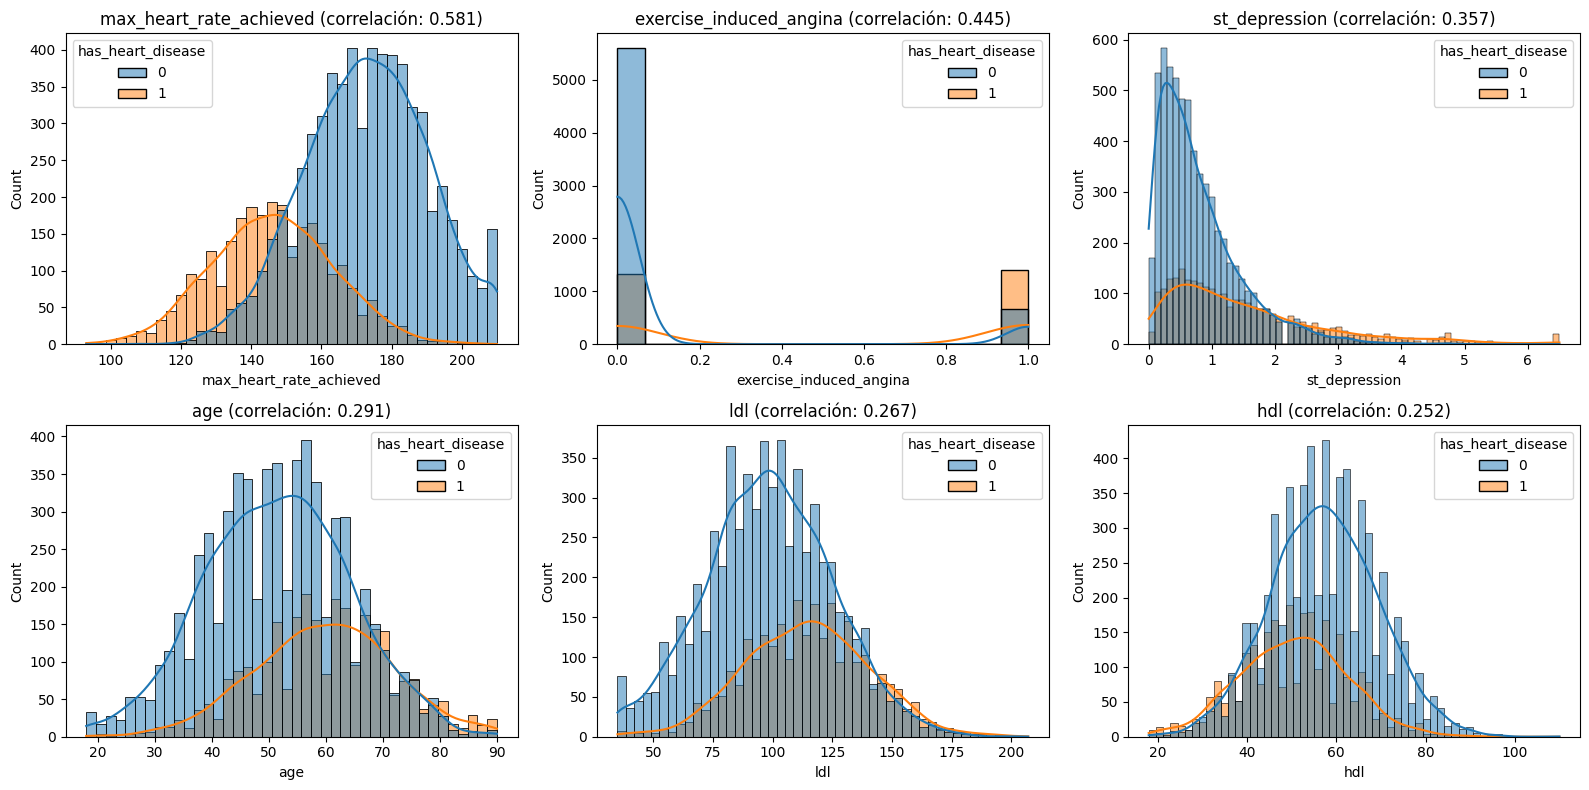


Variables categóricas encontradas: ['sex', 'chest_pain_type', 'smoker_status']


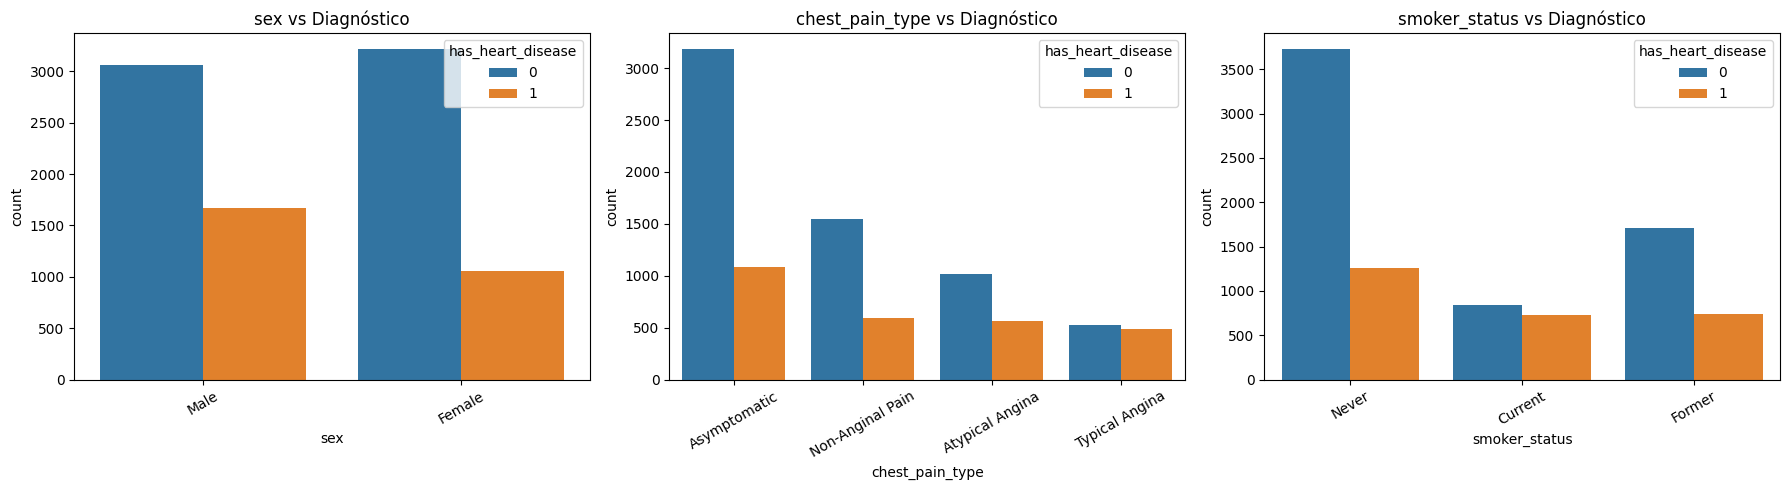

In [ ]:
# ============================================================
# 1. Variables NUMÉRICAS: correlación con la variable objetivo
# ============================================================
df_numerico = df.select_dtypes(include=['int64', 'float64', 'bool'])

correlaciones = df_numerico.corr()['has_heart_disease'].abs().sort_values(ascending=False)

print("Correlación de variables numéricas con has_heart_disease:")
print(correlaciones)

# Seleccionar las top 6 más correlacionadas (excluyendo la propia variable objetivo y el id)
top_variables = (
    correlaciones.drop(['has_heart_disease', 'patient_id'], errors='ignore')
    .head(6)
    .index.tolist()
)
print(f"\nVariables numéricas seleccionadas para graficar: {top_variables}")

# Graficar cada una comparando contra el diagnóstico
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(top_variables):
    sns.histplot(data=df, x=var, hue='has_heart_disease', kde=True, ax=axes[i])
    axes[i].set_title(f'{var} (correlación: {correlaciones[var]:.3f})')

plt.tight_layout()
plt.show()

# ============================================================
# 2. Variables CATEGÓRICAS: distribución frente al diagnóstico
# ============================================================
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables categóricas encontradas: {variables_categoricas}")

fig, axes = plt.subplots(1, len(variables_categoricas), figsize=(6*len(variables_categoricas), 5))
axes = axes if len(variables_categoricas) > 1 else [axes]

for i, var in enumerate(variables_categoricas):
    sns.countplot(data=df, x=var, hue='has_heart_disease', ax=axes[i])
    axes[i].set_title(f'{var} vs Diagnóstico')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# **4. Transformación de variables**

In [ ]:
variables_nominales = [
    "sex",
    "chest_pain_type",
    "smoker_status"
]

variables_ordinales = [
    "exercise_induced_angina",
    "family_history",
    "wearable_owner"
]

df_encoded = df.copy()

# 1. Variables nominales (One-Hot Encoding) y forzar a entero
if variables_nominales:
    df_encoded = pd.get_dummies(df_encoded, columns=variables_nominales, drop_first=True, dtype=int)

# 2. Variables ordinales (Ordinal Encoding) y asegurar tipo numérico
if variables_ordinales:
    encoder = OrdinalEncoder()
    df_encoded[variables_ordinales] = encoder.fit_transform(df_encoded[variables_ordinales])
    df_encoded[variables_ordinales] = df_encoded[variables_ordinales].astype(int)

print("Transformación completada con éxito.")
display(df_encoded.sample(4))

Transformación completada con éxito.


,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,sex_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,smoker_status_Former,smoker_status_Never
4401,4402,47,108,73,178,64,96,109,125,5.9,...,1,7685,63.3,0,0,0,0,0,0,0
8073,8074,32,115,76,183,72,102,74,139,6.4,...,1,7473,63.4,0,0,0,0,1,1,0
5047,5048,58,122,76,169,61,84,173,109,5.8,...,1,5541,72.3,0,1,0,1,0,0,1
5678,5679,58,128,82,148,42,99,107,111,5.5,...,0,8450,66.1,0,1,0,0,0,0,1


# **5. Divicion del dataset**

In [ ]:
y=None
X = None
if "has_heart_disease" in df_encoded.columns:
  y = df_encoded['has_heart_disease']
  X = df_encoded.drop(columns=['has_heart_disease'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_train = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"Dimensiones de entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones de prueba (X_test): {X_test.shape}")
print(f"Dimensiones de validación (X_val): {X_val.shape}")
print(f"Dimensiones de entrenamiento (y_train): {y_train.shape}")
print(f"Dimensiones de prueba (y_test): {y_test.shape}")
print(f"Dimensiones de validación (y_val): {y_val.shape}")

Dimensiones de entrenamiento (X_train): (5760, 29)
Dimensiones de prueba (X_val): (1440, 29)
Dimensiones de entrenamiento (y_train): (5760,)
Dimensiones de prueba (y_val): (1440,)


# **6. Escalado de la variables**

In [ ]:
# Identificar variables numéricas a escalar (excluyendo nominales y ordinales ya codificadas)
variables_numericas = [
    col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
    if col not in variables_nominales
    and col not in variables_ordinales
]

# Escalar: fit SOLO en train, transform en train y test
scaler = StandardScaler()

X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])
X_val[variables_numericas] = scaler.transform(X_val[variables_numericas])

print("Escalado completado sin leakage.")
X_train.sample(4)

Escalado completado sin leakage.


,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,stress_score,wearable_owner,daily_steps,diet_quality_score,sex_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,smoker_status_Former,smoker_status_Never
4917,0.181086,-0.080229,0.081041,0.201895,0.378393,-0.264359,-0.013972,0.605890,-0.505703,-1.139763,...,0.932336,0,-1.055902,0.252386,0.955835,2.160854,-0.560775,-0.359431,-0.616686,0.900417
3652,-0.304882,2.005573,0.663446,-0.255513,-1.511232,-0.673184,-1.511034,0.389973,1.918218,1.754426,...,-0.463030,1,-0.066128,1.273789,-1.046205,2.160854,-0.560775,-0.359431,-0.616686,0.900417
6287,0.707391,-0.698245,-1.666174,-2.816999,0.935987,1.207409,0.278138,0.586261,-0.726059,-0.271506,...,-0.288610,0,-0.072627,1.929419,0.955835,2.160854,-0.560775,-0.359431,-0.616686,0.900417
3579,-0.332926,-2.166032,-1.302171,-1.627738,-0.117246,-1.245538,0.314652,0.802178,-0.197204,-0.416216,...,-0.406967,0,0.438508,-0.092682,0.955835,2.160854,-0.560775,-0.359431,-0.616686,0.900417


# **7. Definición de la arquitectura de la red neuronal**

In [ ]:
modelo = Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.L2(0.01)),
    layers.Dropout(0.3),    # Ayuda en el proceso de eliminar sobreajuste mediante tecnica apagado de neuronas para evitar aprender ruido
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.L2(0.01)),
    layers.Dense(1, activation="sigmoid")
])

# **8. Compilar el modelo**

In [ ]:
modelo.compile(
    #optimizer="Adam",
    optimizer=Adam(learning_rate=0.001),
    loss = "binary_crossentropy",
    metrics = ["accuracy", Precision(name="precision"), Recall(name="recall"), AUC(name="auc")]
)

In [ ]:
# Cálculo de pesos de clase para manejar el desbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict_nn = dict(enumerate(class_weights))

In [ ]:
early_stop_nn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
history = modelo.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    class_weight=class_weight_dict_nn, # Corrected argument name
    callbacks=[early_stop_nn],
    batch_size=32,
    shuffle=True,    #los datos de entrenamiento se mezclan aleatoriamente en cada epoca
    verbose=1
)

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6899 - auc: 0.7784 - loss: 0.9960 - precision: 0.4923 - recall: 0.7331 - val_accuracy: 0.8118 - val_auc: 0.8953 - val_loss: 0.7656 - val_precision: 0.6497 - val_recall: 0.8211
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8264 - auc: 0.9100 - loss: 0.6680 - precision: 0.6700 - recall: 0.8419 - val_accuracy: 0.8424 - val_auc: 0.9249 - val_loss: 0.5832 - val_precision: 0.6961 - val_recall: 0.8509
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8571 - auc: 0.9359 - loss: 0.5212 - precision: 0.7194 - recall: 0.8666 - val_accuracy: 0.8597 - val_auc: 0.9358 - val_loss: 0.4739 - val_precision: 0.7349 - val_recall: 0.8394
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - auc: 0.9462 - loss: 0.4409 - precision: 0.7467 - recall: 0.8763 - val_accuracy: 0.8743 - val_auc: 0.9432 - val_loss: 0.4132 - val_precision: 0.7629 - val_recall: 0.8486
Epoch 5/100
180/180 ━━━━━━━━

# Curvas de aprendizaje
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Curva de pérdida')

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend(); plt.title('Curva de AUC')
plt.tight_layout()
plt.show()

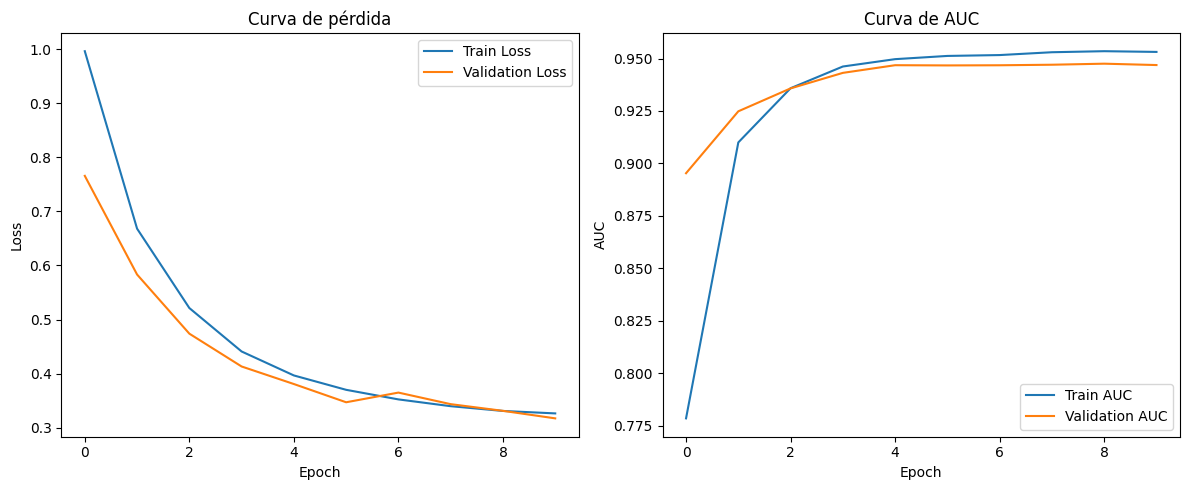

In [ ]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Curva de pérdida')

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend(); plt.title('Curva de AUC')
plt.tight_layout()
plt.show()

In [ ]:
# Predicción de probabilidades en el conjunto de prueba
y_pred_prob_nn = modelo.predict(X_test).ravel()

# Cálculo del mejor umbral con Precision-Recall Curve
precisions_nn, recalls_nn, thresholds_nn = precision_recall_curve(y_test, y_pred_prob_nn)
f1_scores_nn = 2 * (precisions_nn * recalls_nn) / (precisions_nn + recalls_nn + 1e-9)
best_threshold_nn = thresholds_nn[np.argmax(f1_scores_nn)]
print(f"Mejor umbral encontrado (maximizando F1-score): {best_threshold_nn:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mejor umbral encontrado (maximizando F1-score): 0.5618



Matriz de Confusión con umbral ajustado:


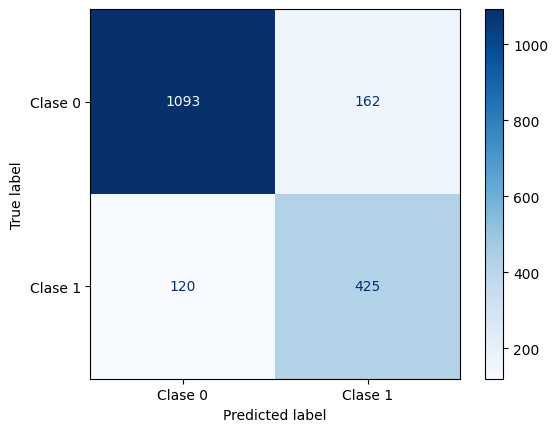


Reporte de Clasificación con umbral ajustado:
              precision    recall  f1-score   support

     Clase 0       0.90      0.87      0.89      1255
     Clase 1       0.72      0.78      0.75       545

    accuracy                           0.84      1800
   macro avg       0.81      0.83      0.82      1800
weighted avg       0.85      0.84      0.84      1800



In [ ]:
# Evaluación con el umbral ajustado
y_pred_ajustado_nn = (y_pred_prob_nn >= best_threshold_nn).astype(int)

print("\nMatriz de Confusión con umbral ajustado:")
cm_nn = confusion_matrix(y_test, y_pred_ajustado_nn)
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Clase 0', 'Clase 1']).plot(cmap='Blues')
plt.show()

print("\nReporte de Clasificación con umbral ajustado:")
print(classification_report(y_test, y_pred_ajustado_nn, target_names=['Clase 0', 'Clase 1']))

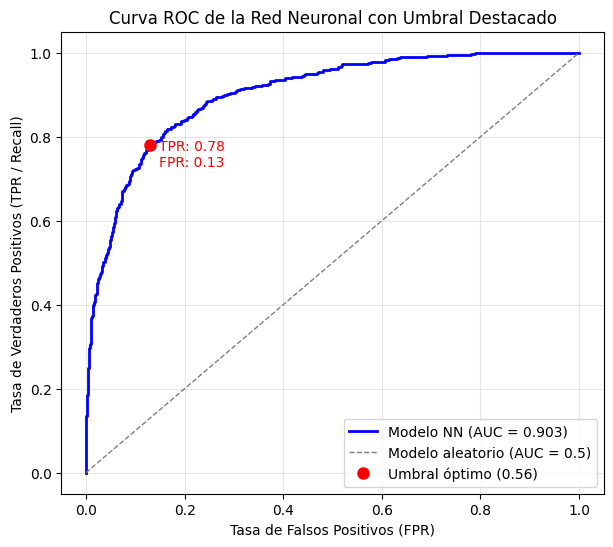

In [ ]:
# Curva ROC con umbral destacado
fpr_nn, tpr_nn, thresholds_roc_nn = roc_curve(y_test, y_pred_prob_nn)
auc_score_nn = roc_auc_score(y_test, y_pred_prob_nn)

# Encontrar el punto en la curva ROC más cercano al mejor umbral
threshold_index_nn = np.argmin(np.abs(thresholds_roc_nn - best_threshold_nn))
fpr_at_threshold_nn = fpr_nn[threshold_index_nn]
tpr_at_threshold_nn = tpr_nn[threshold_index_nn]

plt.figure(figsize=(7, 6))
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label=f'Modelo NN (AUC = {auc_score_nn:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')

# Marcar el punto correspondiente al umbral elegido
plt.plot(fpr_at_threshold_nn, tpr_at_threshold_nn, 'o', color='red', markersize=8,
         label=f'Umbral óptimo ({best_threshold_nn:.2f})')
plt.text(fpr_at_threshold_nn + 0.02, tpr_at_threshold_nn - 0.05,
         f'TPR: {tpr_at_threshold_nn:.2f}\nFPR: {fpr_at_threshold_nn:.2f}',
         color='red', fontsize=10)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC de la Red Neuronal con Umbral Destacado')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()